## 1. Импорты и настройки

In [ ]:
import os, sys, re, pickle, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
from gensim.models import KeyedVectors
import joblib
import nltk
from openai import OpenAI
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", ".."))
print("Working dir:", os.getcwd())

load_dotenv()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

plt.rcParams.update(
    {
        "figure.figsize": (14, 6),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    }
)
sns.set_style("whitegrid")

SEED = 42
np.random.seed(SEED)

c:\Users\pozoy\Desktop\MISIS\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working dir: c:\Users\pozoy\Desktop\MISIS\final
Device: cpu


## 2. Данные: тот же сплит, что и в all_comparison

test_size=0.1, stratify=label, SEED=42 — 441 пример, 219 правды + 222 фейка.
Все модели уже видели свои train-сплиты, эти 441 — hold-out, который никто не видел при обучении.

In [ ]:
DATA_PATH = "data/ready_dataset.csv"
df = pd.read_csv(DATA_PATH)
df = df[["headline_clean", "body_clean", "combined_text", "label"]].dropna()
df["headline_clean"] = df["headline_clean"].astype(str).str.strip()
df["body_clean"] = df["body_clean"].astype(str).str.strip()
df["combined_text"] = df["combined_text"].astype(str).str.strip()
df = df[(df["headline_clean"] != "") & (df["body_clean"] != "")]
df["label"] = pd.to_numeric(df["label"], errors="coerce").astype(int)
df = df.reset_index(drop=True)

train_df, test_df = train_test_split(
    df, test_size=0.1, random_state=SEED, stratify=df["label"]
)
test_df = test_df.reset_index(drop=True)

y_true = test_df["label"].values
headlines = test_df["headline_clean"].astype(str).tolist()
bodies = test_df["body_clean"].astype(str).tolist()
combined_text = test_df["combined_text"].astype(str).tolist()

print(f"Тестовая выборка: {len(test_df)} примеров (in-distribution hold-out)")
print(f"  Реальные (1): {(y_true == 1).sum()}")
print(f"  Фейки    (0): {(y_true == 0).sum()}")

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words("russian"))


def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = re.sub(r"http\S+|www\S+|https\S+", "", t)
    t = re.sub(r"\S+@\S+", "", t)
    t = re.sub(r"<.*?>", "", t)
    t = re.sub(r"[^а-яёa-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return " ".join(w for w in t.split() if w not in STOPWORDS and len(w) > 2)

Тестовая выборка: 441 примеров (in-distribution hold-out)
  Реальные (1): 219
  Фейки    (0): 222


## 3. Загрузка моделей

In [ ]:
from peft import PeftModel

GPT_BASE = "ai-forever/rugpt3small_based_on_gpt2"

tfidf_vec = pickle.load(open("models/tfidf_vectorizer_tf.pkl", "rb"))
tfidf_lr = pickle.load(open("models/logistic_regression_model_tf.pkl", "rb"))
tfidf_nb = pickle.load(open("models/naive_bayes_model_tf.pkl", "rb"))
tfidf_rf = pickle.load(open("models/random_forest_model_tf.pkl", "rb"))
print("TF-IDF загружены")

w2v_kv = KeyedVectors.load("models/w2v_vectors.kv")
w2v_lr = pickle.load(open("models/logisticregression_model.pkl", "rb"))
w2v_rf = pickle.load(open("models/randomforest_model.pkl", "rb"))
print("Word2Vec загружены")

rubert_tok = AutoTokenizer.from_pretrained("models/rubert/best_model")
rubert_mdl = AutoModelForSequenceClassification.from_pretrained(
    "models/rubert/best_model"
).to(DEVICE)
rubert_mdl.eval()
print("RuBERT загружен")

rugpt_tok = AutoTokenizer.from_pretrained("./models/llm_v3_tuned/lora_adapter")
rugpt_tok.padding_side = "left"
if rugpt_tok.pad_token is None:
    rugpt_tok.pad_token = rugpt_tok.eos_token
rugpt_base = AutoModelForSequenceClassification.from_pretrained(GPT_BASE, num_labels=2)
rugpt_base.config.pad_token_id = rugpt_tok.pad_token_id
rugpt_mdl = (
    PeftModel.from_pretrained(rugpt_base, "./models/llm_v3_tuned/lora_adapter")
    .merge_and_unload()
    .to(DEVICE)
)
rugpt_mdl.eval()
print("ruGPT загружен")

TF-IDF загружены
Word2Vec загружены
RuBERT загружен


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at ai-forever/rugpt3small_based_on_gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ruGPT-3 + LoRA загружен

Локальные модели готовы


## 4. Инференс классических моделей и RuBERT

In [ ]:
def doc_vector(tokens, kv_model):
    vecs = [kv_model[w] for w in tokens if w in kv_model]
    return (
        np.vstack(vecs).mean(axis=0)
        if vecs
        else np.zeros(kv_model.vector_size, dtype=np.float32)
    )


print("TF-IDF")
h_clean = [preprocess_text(h) for h in headlines]
b_clean = [preprocess_text(b) for b in bodies]
X_tfidf = tfidf_vec.transform([f"{h} {b}" for h, b in zip(h_clean, b_clean)])
preds_tfidf_lr = tfidf_lr.predict(X_tfidf)
probs_tfidf_lr = tfidf_lr.predict_proba(X_tfidf)[:, 1]
preds_tfidf_nb = tfidf_nb.predict(X_tfidf)
probs_tfidf_nb = tfidf_nb.predict_proba(X_tfidf)[:, 1]
preds_tfidf_rf = tfidf_rf.predict(X_tfidf)
probs_tfidf_rf = tfidf_rf.predict_proba(X_tfidf)[:, 1]

print("Word2Vec")
w2v_feats = []
for h, b in zip(h_clean, b_clean):
    htoks = h.split()[:150]
    btoks = b.split()[:150]
    h_vec = doc_vector(htoks, w2v_kv)
    b_vec = doc_vector(btoks, w2v_kv)
    cos_sim = float(
        np.dot(h_vec, b_vec) / max(np.linalg.norm(h_vec) * np.linalg.norm(b_vec), 1e-8)
    )
    jacc = len(set(htoks) & set(btoks)) / max(1, len(set(htoks) | set(btoks)))
    ovr = len(set(htoks) & set(btoks)) / max(1, len(set(htoks)))
    l2 = float(np.linalg.norm(h_vec - b_vec))
    feat = np.hstack(
        [h_vec, b_vec, np.abs(h_vec - b_vec), h_vec * b_vec, [cos_sim, jacc, ovr, l2]]
    )
    w2v_feats.append(feat)
X_w2v = np.array(w2v_feats)
preds_w2v_lr = w2v_lr.predict(X_w2v)
probs_w2v_lr = w2v_lr.predict_proba(X_w2v)[:, 1]
preds_w2v_rf = w2v_rf.predict(X_w2v)
probs_w2v_rf = w2v_rf.predict_proba(X_w2v)[:, 1]

print("RuBERT")
preds_rubert, probs_rubert = [], []
with torch.no_grad():
    for h, b in tqdm(zip(headlines, bodies), total=len(headlines), desc="RuBERT"):
        enc = rubert_tok(
            f"{h} {b}",
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt",
        )
        out = rubert_mdl(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE),
        )
        p = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        preds_rubert.append(int(np.argmax(p)))
        probs_rubert.append(float(p[1]))
preds_rubert = np.array(preds_rubert)
probs_rubert = np.array(probs_rubert)


TF-IDF...
Word2Vec...
RuBERT...


RuBERT: 100%|██████████| 441/441 [01:25<00:00,  5.16it/s]

Готово


## 5. Инференс ruGPT-3 + LoRA

In [ ]:

print("ruGPT")
preds_rugpt, probs_rugpt = [], []
with torch.no_grad():
    for h, b in tqdm(zip(headlines, bodies), total=len(headlines), desc="ruGPT-3+LoRA"):
        enc = rugpt_tok(
            f"{h} | {b}",
            truncation=True,
            padding="max_length",
            max_length=512,
            return_tensors="pt",
        )
        out = rugpt_mdl(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE),
        )
        p = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        preds_rugpt.append(int(np.argmax(p)))
        probs_rugpt.append(float(p[1]))
preds_rugpt = np.array(preds_rugpt)
probs_rugpt = np.array(probs_rugpt)

ruGPT-3 + LoRA...


ruGPT-3+LoRA: 100%|██████████| 441/441 [03:25<00:00,  2.15it/s]

Готово


## 6. DeepSeek API на тех же 441 примерах

**Конфигурация:**
- **K=24** few-shot (12 фейков + 12 правды, отобраны через TF-IDF cosine)
- **Chain-of-Thought** в системном промпте + явный протокол рассуждения
- **Self-consistency**: 3 голоса на пример (T=0 + 2 голоса с T=0.4), голосование большинством

**Версии кэша:**
- v4 — базовый прогон 441 × 3 голоса (~15–20 минут)
- v5 — второй проход по ошибочным примерам v4 с 7 голосами и усиленным промптом (см. `notebooks/comparsion/_deepseek_second_pass.py`)

Ноутбук подхватывает v5, если файл существует, иначе откатывается к v4. Few-shot примеры берутся из **train-сплита** (тот же SEED, не пересекается с test).

In [ ]:
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

retriever = TfidfVectorizer(
    max_features=20000, ngram_range=(1, 2), min_df=2, sublinear_tf=True
)
train_texts = train_df["combined_text"].astype(str).tolist()
train_labels = train_df["label"].astype(int).tolist()
X_train_tfidf = retriever.fit_transform(train_texts)

K_RETRIEVE = 24 


def retrieve_fewshot(test_text, k=K_RETRIEVE):
    q = retriever.transform([test_text])
    sims = cosine_similarity(q, X_train_tfidf).ravel()
    order = sims.argsort()[::-1]
    target_per_class = k // 2
    by_class = {0: [], 1: []}
    for i in order:
        lbl = train_labels[i]
        if len(by_class[lbl]) < target_per_class:
            by_class[lbl].append(
                {"text": train_texts[i], "label": lbl, "sim": float(sims[i])}
            )
        if (
            len(by_class[0]) >= target_per_class
            and len(by_class[1]) >= target_per_class
        ):
            break
    examples = by_class[0] + by_class[1]
    random.Random(42).shuffle(examples)
    return examples


sample_query = combined_text[0]
sample_fs = retrieve_fewshot(sample_query)

TF-IDF ретривер построен на 3966 train-примерах
K_RETRIEVE = 24 (по 12 на класс)

Демо для test[0]:
  query: буду выступать никол пашинян обратился путину просьбой предоставлении гражданства премьер министр армении никол пашинян провёл телефонные переговоры п...
  получено 24 примеров, sim диапазон: 0.065 — 0.224


In [ ]:
from collections import Counter

DEEPSEEK_API_KEY = os.environ["DEEPSEEK_API_KEY"]
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
DEEPSEEK_MODEL = "deepseek-chat"

ds_client = OpenAI(api_key=DEEPSEEK_API_KEY, base_url=DEEPSEEK_BASE_URL)

DS_SYSTEM_PROMPT = (
    "You classify Russian-language news as REAL (label=1) or FAKE (label=0). "
    "Texts are lemmatized (no punctuation, no headlines, single line). "
    "Stylistic signals are USELESS — match TOPICAL and SEMANTIC patterns from labeled examples below. "
    "For each query you receive 24 retrieved examples (12 fakes, 12 reals) chosen by similarity. "
    "Reasoning protocol: "
    "(1) identify the 2-3 most semantically similar labeled examples, "
    "(2) check whether the query asserts the same kind of claim (event/topic/character), "
    "(3) note any subtle markers: implausible specifics, conspiratorial framing, fabricated quotes → fake; "
    "documented events, official sources, factual phrasing → real. "
    'Output JSON only: {"reasoning": "1-2 sentences", "label": 0 or 1, "confidence": "low|medium|high"}.'
)


def build_messages(text, fewshot):
    msgs = [{"role": "system", "content": DS_SYSTEM_PROMPT}]
    for ex in fewshot:
        msgs.append(
            {
                "role": "user",
                "content": f'TEXT:\n{ex["text"][:1200]}\n\nClassify (return JSON):',
            }
        )
        reason = (
            "similar to known fake (fabricated/satirical/implausible claim)."
            if ex["label"] == 0
            else "similar to known real (documented event with verifiable sources)."
        )
        msgs.append(
            {
                "role": "assistant",
                "content": json.dumps(
                    {"reasoning": reason, "label": ex["label"], "confidence": "high"},
                    ensure_ascii=False,
                ),
            }
        )
    msgs.append(
        {"role": "user", "content": f"TEXT:\n{text[:1200]}\n\nClassify (return JSON):"}
    )
    return msgs


def parse_deepseek(content):
    content = content.strip()
    if "```" in content:
        for part in content.split("```"):
            part = part.strip()
            if part.startswith("json"):
                part = part[4:].strip()
            if part.startswith("{"):
                content = part
                break
    matches = re.findall(r"\{.*?\}", content, re.DOTALL)
    if matches:
        for m in reversed(matches):
            data = json.loads(m)
            for k in data:
                if k.lower() in ("label", "is_true", "is_real", "class", "result"):
                    raw = data[k]
                    if isinstance(raw, bool):
                        return int(raw)
                    if isinstance(raw, (int, float)):
                        return int(bool(int(raw)))
                    s = str(raw).strip().lower()
                    return 1 if s in ("1", "true", "real", "правда") else 0

    m = re.findall(r'"label"\s*:\s*([01])', content.lower())
    if m:
        return int(m[-1])
    m = re.findall(r'"label"\s*:\s*(true|false)', content.lower())
    if m:
        return 1 if m[-1] == "true" else 0
    return None


def deepseek_call(text, fewshot, temperature, max_retries=3):
    for attempt in range(max_retries):
        try:
            r = ds_client.chat.completions.create(
                model=DEEPSEEK_MODEL,
                messages=build_messages(text, fewshot),
                max_tokens=200,
                temperature=temperature,
                stream=False,
            )
            label = parse_deepseek(r.choices[0].message.content.strip())
            if label is not None:
                return label
        except Exception:
            pass
        time.sleep(0.5)
    return None


N_VOTES = 3  
TEMPERATURE_VOTE = 0.4  


def deepseek_classify_voting(text, n_votes=N_VOTES):
    fewshot = retrieve_fewshot(text)
    first = deepseek_call(text, fewshot, temperature=0.0)
    votes = [first] if first is not None else []
    for _ in range(n_votes - 1):
        v = deepseek_call(text, fewshot, temperature=TEMPERATURE_VOTE)
        if v is not None:
            votes.append(v)
    if not votes:
        return 1 
    return Counter(votes).most_common(1)[0][0]


print(
    f"DeepSeek v4 client готов: K={K_RETRIEVE}-shot, CoT, {N_VOTES}-vote self-consistency (T=0 + 2×T={TEMPERATURE_VOTE})"
)

DeepSeek v4 client готов: K=24-shot, CoT, 3-vote self-consistency (T=0 + 2×T=0.4)


In [ ]:
V5_PATH = Path("models/deepseek/predictions_441_v5.csv")
V4_PATH = Path("models/deepseek/predictions_441_v4.csv")
V4_PATH.parent.mkdir(parents=True, exist_ok=True)

cache_df = None
DS_CACHE = V5_PATH if V5_PATH.exists() else V4_PATH

if V5_PATH.exists():
    cache_df = pd.read_csv(V5_PATH)
    print(f"Загружен кэш v5: {V5_PATH}")
elif V4_PATH.exists():
    cache_df = pd.read_csv(V4_PATH)
    print(f"Загружен кэш v4: {V4_PATH}")

if cache_df is not None and len(cache_df) == len(test_df):
    preds_deepseek = cache_df["pred"].values.astype(int)
    print(f"Загружено {len(preds_deepseek)} предсказаний из кэша")
else:
    if cache_df is not None:
        print(f"Кэш частичный ({len(cache_df)}/{len(test_df)}) — продолжаем")
        preds_deepseek = cache_df["pred"].values.astype(int).tolist()
        start_idx = len(preds_deepseek)
    else:
        preds_deepseek = []
        start_idx = 0

    for i in tqdm(
        range(start_idx, len(combined_text)),
        desc=f"DeepSeek ({K_RETRIEVE}-shot, {N_VOTES}-vote)",
    ):
        preds_deepseek.append(deepseek_classify_voting(combined_text[i]))
        if (i + 1) % 50 == 0:
            pd.DataFrame({"true_label": y_true[: i + 1], "pred": preds_deepseek}).to_csv(V4_PATH, index=False)
        time.sleep(0.1)

    preds_deepseek = np.array(preds_deepseek)
    pd.DataFrame({"true_label": y_true, "pred": preds_deepseek}).to_csv(V4_PATH, index=False)
    print(f"Сохранено в {V4_PATH}")

preds_deepseek = np.asarray(preds_deepseek, dtype=int)
probs_deepseek = preds_deepseek.astype(float)
acc_ds = accuracy_score(y_true, preds_deepseek)
err_ds = (preds_deepseek != y_true).sum()
print(f"DeepSeek accuracy ({DS_CACHE.name}): {acc_ds:.4f}")
print(f"  Ошибок: {err_ds} / {len(y_true)}")
cm_ds = confusion_matrix(y_true, preds_deepseek)
print(f"  TN={cm_ds[0,0]}  FP={cm_ds[0,1]}  FN={cm_ds[1,0]}  TP={cm_ds[1,1]}")


Загружен кэш v5: models\deepseek\predictions_441_v5.csv
Загружено 441 предсказаний из кэша
DeepSeek accuracy (predictions_441_v5.csv): 0.9864
  Ошибок: 6 / 441
  TN=218  FP=4  FN=2  TP=217


## 7. Сводная таблица метрик

In [10]:
all_models = {
    "LR + TF-IDF": {
        "preds": preds_tfidf_lr,
        "probs": probs_tfidf_lr,
        "category": "Классическая",
    },
    "NB + TF-IDF": {
        "preds": preds_tfidf_nb,
        "probs": probs_tfidf_nb,
        "category": "Классическая",
    },
    "RF + TF-IDF": {
        "preds": preds_tfidf_rf,
        "probs": probs_tfidf_rf,
        "category": "Классическая",
    },
    "LR + Word2Vec": {
        "preds": preds_w2v_lr,
        "probs": probs_w2v_lr,
        "category": "Классическая",
    },
    "RF + Word2Vec": {
        "preds": preds_w2v_rf,
        "probs": probs_w2v_rf,
        "category": "Классическая",
    },
    "RuBERT": {"preds": preds_rubert, "probs": probs_rubert, "category": "Трансформер"},
    "ruGPT-3 + LoRA": {
        "preds": preds_rugpt,
        "probs": probs_rugpt,
        "category": "LLM (локальная)",
    },
    "DeepSeek (API)": {
        "preds": preds_deepseek,
        "probs": probs_deepseek,
        "category": "LLM (API)",
    },
}

rows = []
for name, d in all_models.items():
    rows.append(
        {
            "Модель": name,
            "Категория": d["category"],
            "Accuracy": accuracy_score(y_true, d["preds"]),
            "F1": f1_score(y_true, d["preds"], average="weighted"),
            "Precision": precision_score(y_true, d["preds"], average="weighted"),
            "Recall": recall_score(y_true, d["preds"], average="weighted"),
        }
    )

results_df = (
    pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
)
results_df.index = range(1, len(results_df) + 1)
results_df.style.format(
    {"Accuracy": "{:.4f}", "F1": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}"}
).highlight_max(subset=["Accuracy", "F1", "Precision", "Recall"], color="#2d5f2d")

,Модель,Категория,Accuracy,F1,Precision,Recall
1,DeepSeek (API),LLM (API),0.9864,0.9864,0.9864,0.9864
2,RuBERT,Трансформер,0.9819,0.9819,0.9819,0.9819
3,ruGPT-3 + LoRA,LLM (локальная),0.9705,0.9705,0.9713,0.9705
4,LR + TF-IDF,Классическая,0.9660,0.9660,0.9671,0.9660
5,RF + TF-IDF,Классическая,0.9637,0.9637,0.9643,0.9637
6,NB + TF-IDF,Классическая,0.9501,0.9501,0.9519,0.9501
7,RF + Word2Vec,Классическая,0.9501,0.9501,0.9504,0.9501
8,LR + Word2Vec,Классическая,0.9297,0.9297,0.9304,0.9297


## 8. Столбчатые диаграммы (Accuracy и F1)

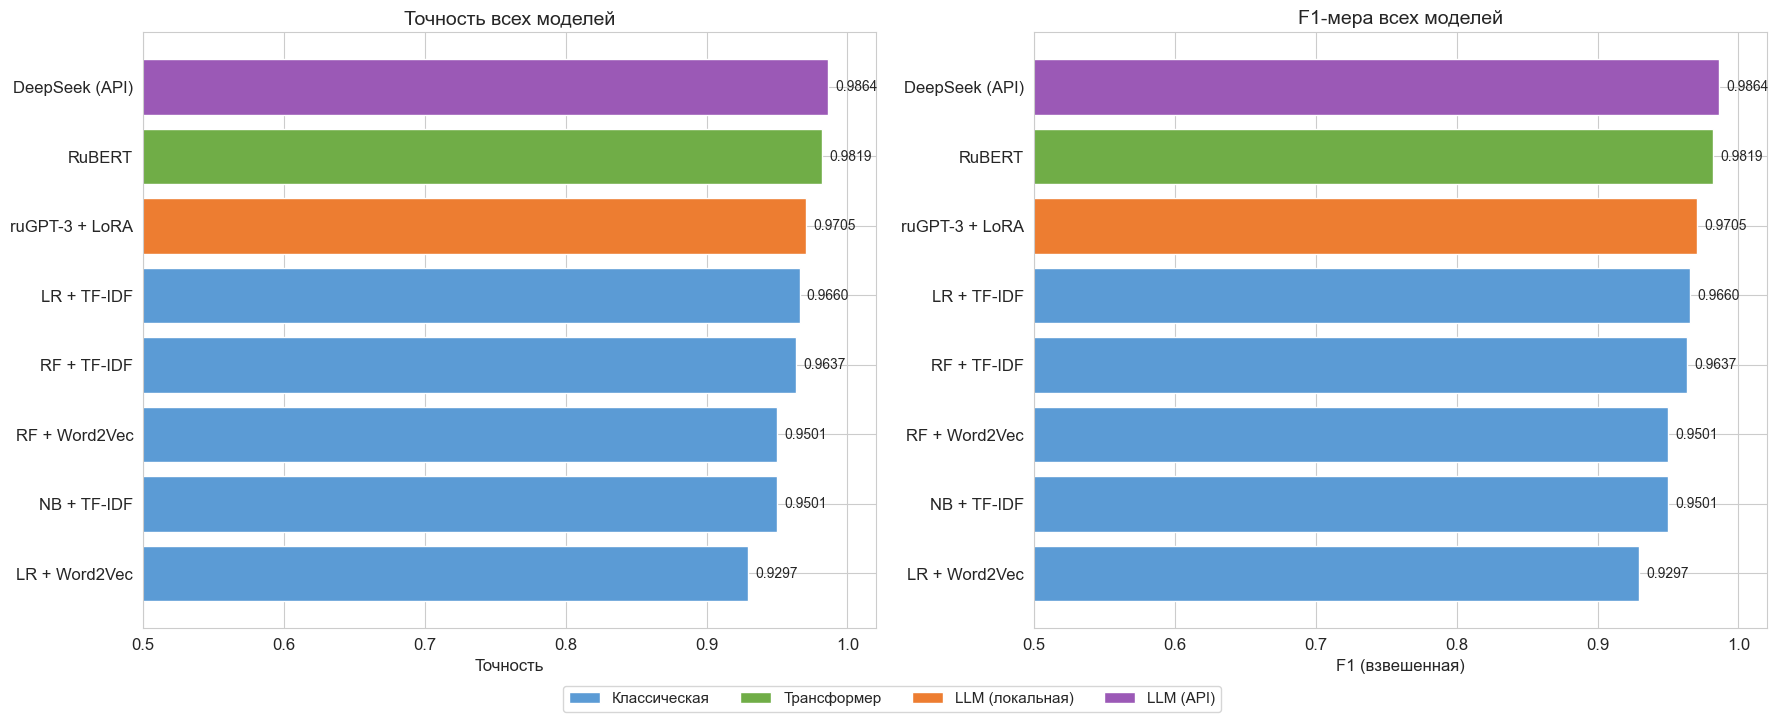

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
df_sorted = results_df.sort_values("Accuracy", ascending=True)
colors = {
    "Классическая": "#5B9BD5",
    "Трансформер": "#70AD47",
    "LLM (локальная)": "#ED7D31",
    "LLM (API)": "#9B59B6",
}
bar_colors = [colors[c] for c in df_sorted["Категория"]]

axes[0].barh(df_sorted["Модель"], df_sorted["Accuracy"], color=bar_colors)
axes[0].set_xlabel("Точность")
axes[0].set_title("Точность всех моделей")
axes[0].set_xlim(0.5, 1.02)
for i, val in enumerate(df_sorted["Accuracy"]):
    axes[0].text(val + 0.005, i, f"{val:.4f}", va="center", fontsize=10)

axes[1].barh(df_sorted["Модель"], df_sorted["F1"], color=bar_colors)
axes[1].set_xlabel("F1 (взвешенная)")
axes[1].set_title("F1-мера всех моделей")
axes[1].set_xlim(0.5, 1.02)
for i, val in enumerate(df_sorted["F1"]):
    axes[1].text(val + 0.005, i, f"{val:.4f}", va="center", fontsize=10)

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
plt.savefig("assets/final_comparsion_accuracy_f1.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Все 4 метрики — группированная диаграмма

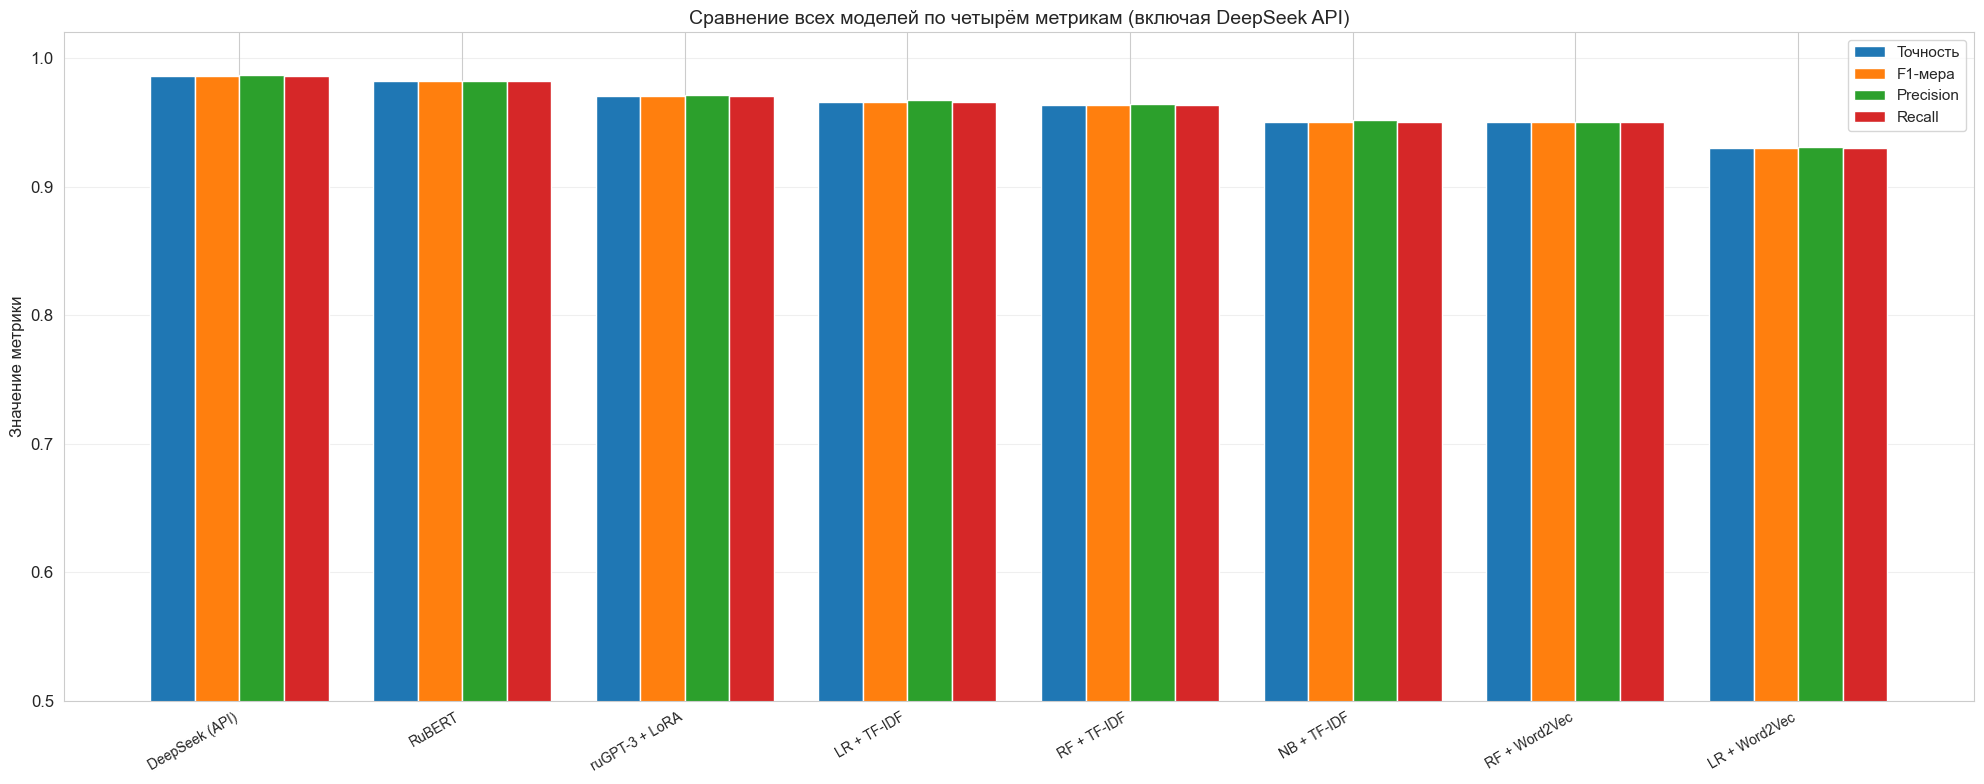

In [12]:
metrics_cols = ["Accuracy", "F1", "Precision", "Recall"]
rus_labels   = {"Accuracy": "Точность", "F1": "F1-мера", "Precision": "Precision", "Recall": "Recall"}
df_plot = results_df.sort_values("Accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(20, 8))
x = np.arange(len(df_plot))
width = 0.2

for i, metric in enumerate(metrics_cols):
    ax.bar(x + i * width, df_plot[metric], width, label=rus_labels[metric])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_plot["Модель"], rotation=30, ha="right", fontsize=10)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Значение метрики")
ax.set_title("Сравнение всех моделей по четырём метрикам (включая DeepSeek API)")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("assets/final_comparsion_4metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Матрицы ошибок всех моделей

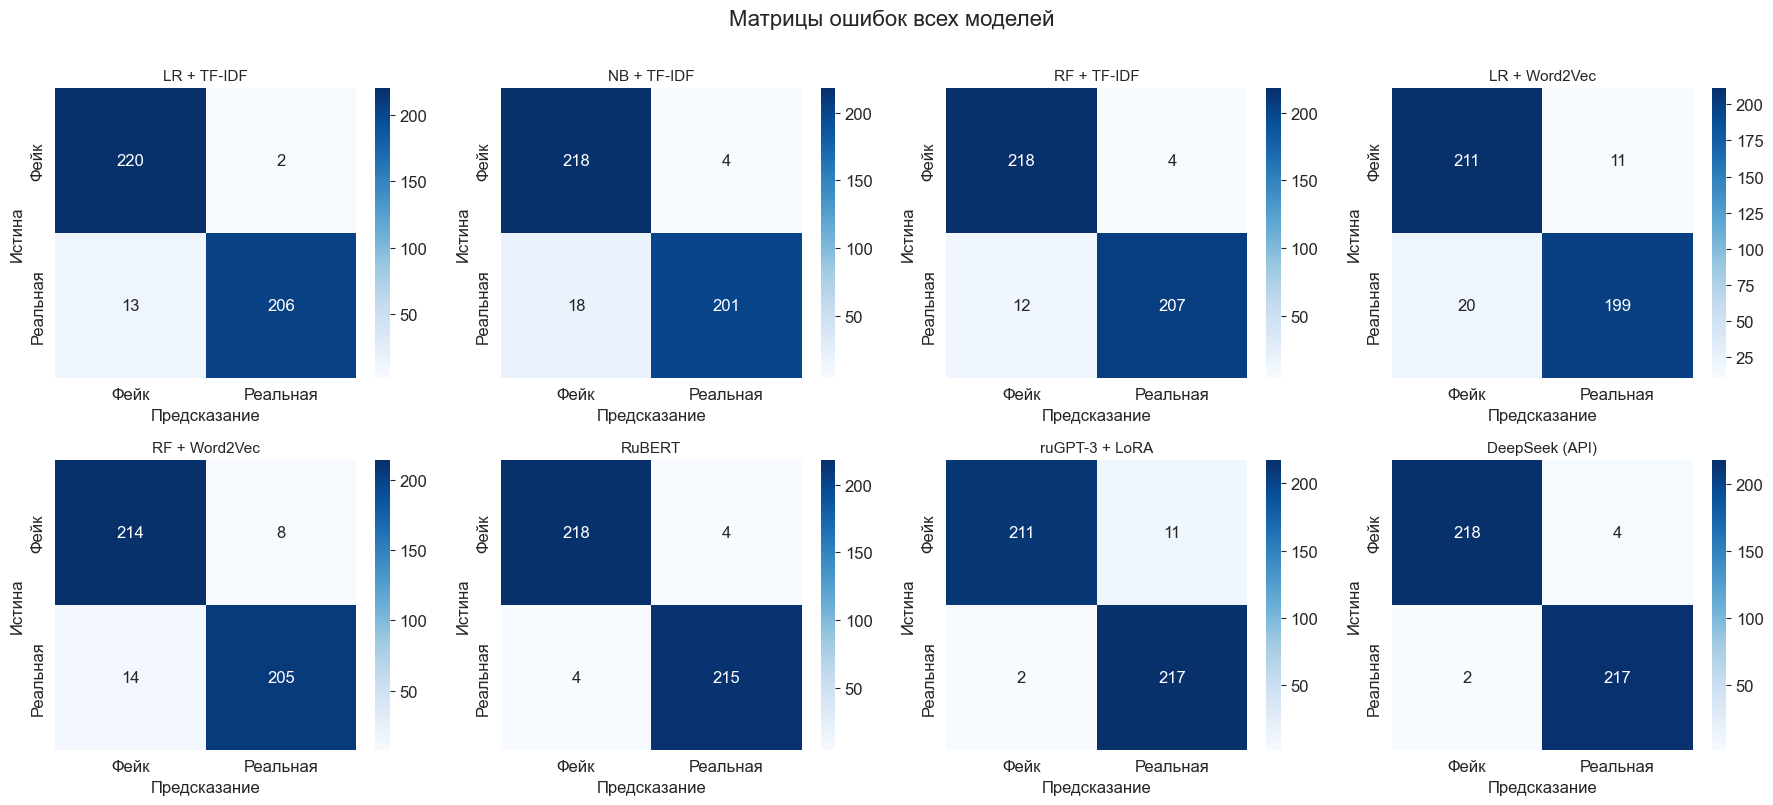

In [13]:
model_names = list(all_models.keys())
n_cols = 4
n_rows = (len(model_names) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_true, all_models[name]["preds"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Фейк", "Реальная"],
        yticklabels=["Фейк", "Реальная"],
    )
    axes[i].set_title(name, fontsize=11)
    axes[i].set_ylabel("Истина")
    axes[i].set_xlabel("Предсказание")

for j in range(len(model_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Матрицы ошибок всех моделей", fontsize=16, y=1.005)
plt.tight_layout()
plt.savefig("assets/final_comparsion_cm.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. ROC-кривые

Для DeepSeek нет калиброванных вероятностей — выводим только дискретную точку (TPR/FPR).

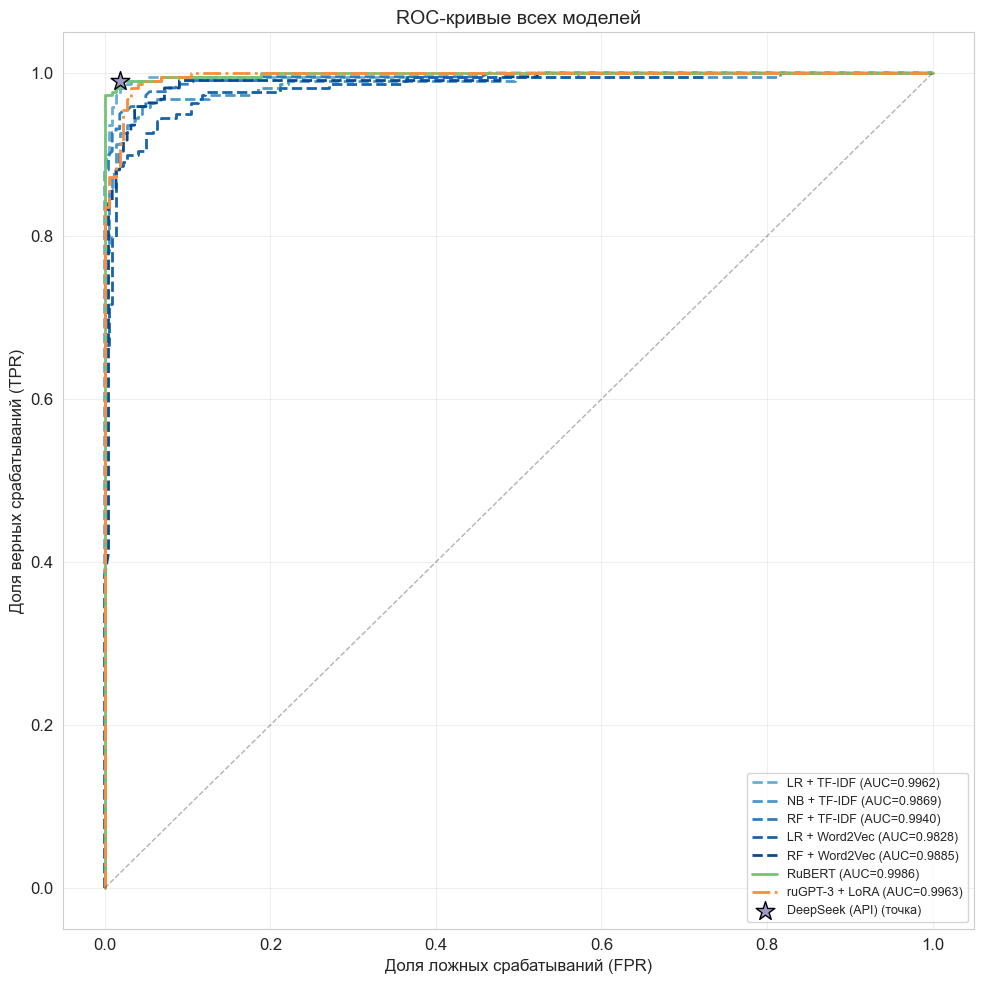

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

line_styles = {
    "Классическая": "--",
    "Трансформер": "-",
    "LLM (локальная)": "-.",
    "LLM (API)": ":",
}
cat_cmaps = {
    "Классическая": plt.cm.Blues,
    "Трансформер": plt.cm.Greens,
    "LLM (локальная)": plt.cm.Oranges,
    "LLM (API)": plt.cm.Purples,
}

cat_counts = {}
for name, d in all_models.items():
    cat = d["category"]
    cat_counts.setdefault(cat, 0)
    idx = cat_counts[cat]
    n_in_cat = sum(1 for v in all_models.values() if v["category"] == cat)
    cmap = cat_cmaps[cat]
    color = cmap(0.5 + 0.4 * idx / max(n_in_cat - 1, 1))
    ls = line_styles[cat]

    if cat == "LLM (API)":
        from sklearn.metrics import confusion_matrix as cm_fn

        cm = cm_fn(y_true, d["preds"])
        tn, fp, fn, tp = cm.ravel()
        fpr_pt = fp / (fp + tn)
        tpr_pt = tp / (tp + fn)
        ax.scatter(
            [fpr_pt],
            [tpr_pt],
            color=color,
            s=200,
            marker="*",
            label=f"{name} (точка)",
            zorder=5,
            edgecolors="black",
            linewidths=1,
        )
    else:
        fpr, tpr, _ = roc_curve(y_true, d["probs"])
        roc_auc = auc(fpr, tpr)
        ax.plot(
            fpr,
            tpr,
            color=color,
            linestyle=ls,
            linewidth=2,
            label=f"{name} (AUC={roc_auc:.4f})",
        )
    cat_counts[cat] += 1

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
ax.set_xlabel("Доля ложных срабатываний (FPR)")
ax.set_ylabel("Доля верных срабатываний (TPR)")
ax.set_title("ROC-кривые всех моделей")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("assets/final_comparsion_roc.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. DeepSeek API vs RuBERT vs ruGPT-3 + LoRA

DeepSeek API vs RuBERT vs ruGPT-3 + LoRA
                Accuracy     F1  Precision  Recall
Модель                                            
DeepSeek (API)    0.9864 0.9864     0.9864  0.9864
RuBERT            0.9819 0.9819     0.9819  0.9819
ruGPT-3 + LoRA    0.9705 0.9705     0.9713  0.9705


--- DeepSeek (API) ---
              precision    recall  f1-score   support

        Фейк     0.9909    0.9820    0.9864       222
    Реальная     0.9819    0.9909    0.9864       219

    accuracy                         0.9864       441
   macro avg     0.9864    0.9864    0.9864       441
weighted avg     0.9864    0.9864    0.9864       441


--- RuBERT ---
              precision    recall  f1-score   support

        Фейк     0.9820    0.9820    0.9820       222
    Реальная     0.9817    0.9817    0.9817       219

    accuracy                         0.9819       441
   macro avg     0.9819    0.9819    0.9819       441
weighted avg     0.9819    0.9819    0.9819       441


--- ruGP

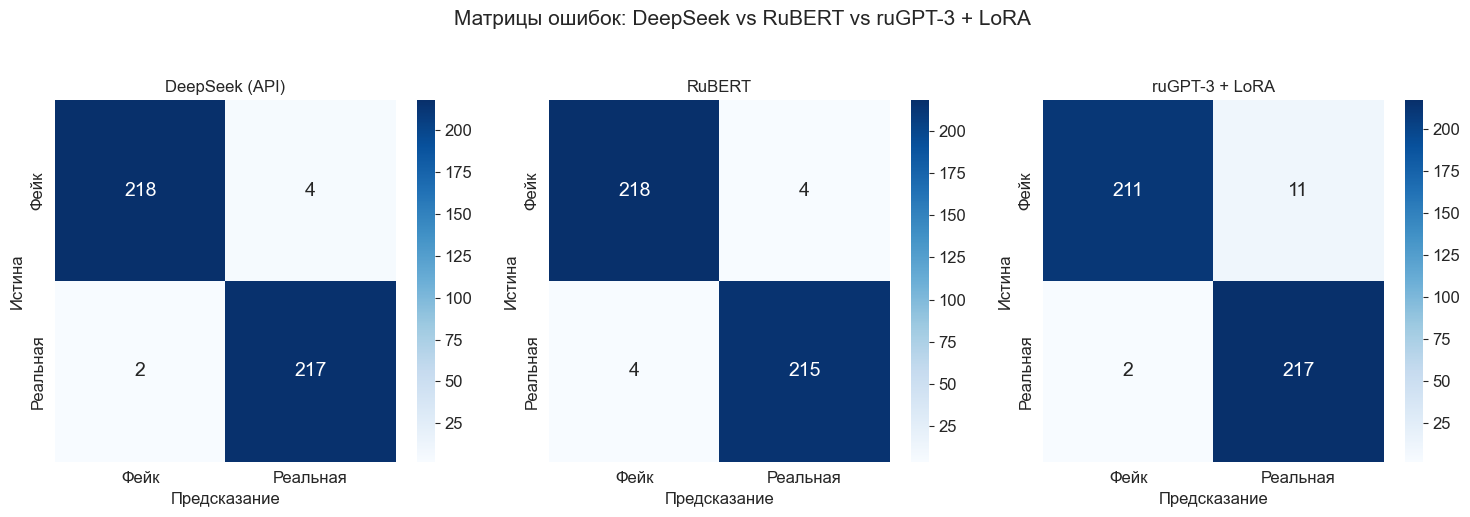

In [ ]:
compare_names = ["DeepSeek (API)", "RuBERT", "ruGPT-3 + LoRA"]
compare_rows = []
for name in compare_names:
    p = all_models[name]["preds"]
    compare_rows.append(
        {
            "Модель": name,
            "Accuracy": accuracy_score(y_true, p),
            "F1": f1_score(y_true, p, average="weighted"),
            "Precision": precision_score(y_true, p, average="weighted"),
            "Recall": recall_score(y_true, p, average="weighted"),
        }
    )
compare_df = pd.DataFrame(compare_rows).set_index("Модель")
print("=" * 50)
print("DeepSeek API vs RuBERT vs ruGPT-3 + LoRA")
print("=" * 50)
print(compare_df.to_string(float_format=lambda x: f"{x:.4f}"))
print()
for name in compare_names:
    print(f"\n--- {name} ---")
    print(
        classification_report(
            y_true,
            all_models[name]["preds"],
            target_names=["Фейк", "Реальная"],
            digits=4,
        )
    )

fig, axes = plt.subplots(1, len(compare_names), figsize=(5 * len(compare_names), 5))
for ax, name in zip(axes, compare_names):
    cm = confusion_matrix(y_true, all_models[name]["preds"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Фейк", "Реальная"],
        yticklabels=["Фейк", "Реальная"],
        annot_kws={"size": 14},
    )
    ax.set_title(name, fontsize=12)
    ax.set_ylabel("Истина")
    ax.set_xlabel("Предсказание")
plt.suptitle(
    "Матрицы ошибок: DeepSeek vs RuBERT vs ruGPT-3 + LoRA", fontsize=15, y=1.03
)
plt.tight_layout()
plt.savefig("assets/final_deepseek_vs_top.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Сохранение результатов

In [ ]:
results_df.to_csv("assets/final_comparsion.csv", index=False)
compare_df.to_csv("assets/final_deepseek_vs_top.csv")
print("Saved:")
for f in [
    "assets/final_comparsion.csv",
    "assets/final_deepseek_vs_top.csv",
    "assets/final_comparsion_accuracy_f1.png",
    "assets/final_comparsion_4metrics.png",
    "assets/final_comparsion_cm.png",
    "assets/final_comparsion_roc.png",
    "assets/final_deepseek_vs_top.png",
    "models/deepseek/predictions_441.csv",
]:
    print(f"  {f}")

Сохранено:
  assets/final_comparsion.csv
  assets/final_deepseek_vs_top.csv
  assets/final_comparsion_accuracy_f1.png
  assets/final_comparsion_4metrics.png
  assets/final_comparsion_cm.png
  assets/final_comparsion_roc.png
  assets/final_deepseek_vs_top.png
  models/deepseek/predictions_441.csv
